In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [26]:
df = pd.read_csv("C:/Users/GOWRI/OneDrive/Desktop/INTERNSHIP PROJECT/NYC.csv")

# ── Basic filtering ──────────────────────────────────────
df = df[df["passenger_count"] > 0]
df = df[df["trip_duration"] > 0]

# ── DateTime features ────────────────────────────────────
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_hour"]     = df["pickup_datetime"].dt.hour
df["pickup_day"]      = df["pickup_datetime"].dt.dayofweek
df["pickup_daytype"]  = df["pickup_day"].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# ── Haversine Distance (km) ──────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["pickup_latitude"],  df["pickup_longitude"],
    df["dropoff_latitude"], df["dropoff_longitude"]
)

# ── Remove zero/invalid distance trips ───────────────────
df = df[df["distance_km"] > 0.1]  # remove trips under 100 metres

# ── Outlier removal (with before/after count) ────────────
print("Rows BEFORE cleaning:", len(df))

df = df[
    (df['trip_duration'].between(60, 7200)) &  # 1 min to 2 hours
    (df['passenger_count'].between(1, 6)) &    # valid passenger count
    (df['distance_km'] < 100)                  # remove unrealistic distances
]

print("Rows AFTER  cleaning:", len(df))
print(f"Removed: {1458584 - len(df):,} outlier rows")

# ── Drop unnecessary columns (keeping vendor_id) ─────────
df = df.drop(['id', 'store_and_fwd_flag', 'pickup_datetime',
              'dropoff_datetime', 'dropoff_latitude',
              'dropoff_longitude'], axis=1, errors='ignore')

# ── Encode daytype ───────────────────────────────────────
df['pickup_daytype'] = df['pickup_daytype'].map({'Weekday': 0, 'Weekend': 1})

# ── Print final columns ──────────────────────────────────
print("\n✅ Data loaded, cleaned & distance added")
print(f"   Shape : {df.shape}")
print(f"\n📋 Final Columns ({len(df.columns)}):")
for col in df.columns:
    print(f"   → {col}")

Rows BEFORE cleaning: 1445310
Rows AFTER  cleaning: 1440246
Removed: 18,338 outlier rows

✅ Data loaded, cleaned & distance added
   Shape : (1440246, 9)

📋 Final Columns (9):
   → vendor_id
   → passenger_count
   → pickup_longitude
   → pickup_latitude
   → trip_duration
   → pickup_hour
   → pickup_day
   → pickup_daytype
   → distance_km


In [45]:
# Select only your required columns
final_df = df[[]]

# Save to specific path
final_df.to_csv(r'C:/Users/GOWRI/OneDrive/Desktop/INTERNSHIP PROJECT/final4_NYC.csv', index=False)

print("✅ File saved successfully!")

✅ File saved successfully!


In [47]:
df.to_csv('final4_NYC.csv', index=False)


In [27]:
X = df.drop('trip_duration', axis=1)
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Training samples(x_train) : {len(X_train):,}")
print(f"✅ Testing  samples(x_test) : {len(X_test):,}")
print(f"✅ Training samples(y_train) : {len(X_train):,}")
print(f"✅ Testing  samples(y_test) : {len(X_test):,}")

✅ Training samples(x_train) : 1,152,196
✅ Testing  samples(x_test) : 288,050
✅ Training samples(y_train) : 1,152,196
✅ Testing  samples(y_test) : 288,050


In [28]:
def evaluate(y_true, y_pred, model_name):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  R² Score : {r2:.4f}   (closer to 1.0 = better)")
    print(f"  MAE      : {mae:.1f} sec  = {mae/60:.1f} min avg error")
    print(f"  RMSE     : {rmse:.1f} sec  = {rmse/60:.1f} min")
    return dict(R2=round(r2,4), MAE_s=round(mae,1), RMSE_s=round(rmse,1))

In [29]:
# Ridge needs scaling (linear model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
yp_ridge = ridge.predict(X_test_scaled)

results_ridge = evaluate(y_test, yp_ridge, "Ridge Regression")


  Ridge Regression
  R² Score : 0.6036   (closer to 1.0 = better)
  MAE      : 281.4 sec  = 4.7 min avg error
  RMSE     : 411.0 sec  = 6.8 min


In [30]:
# No scaling needed — tree-based model
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), 300_000, replace=False)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])
yp_rf = rf.predict(X_test)

results_rf = evaluate(y_test, yp_rf, "Random Forest")

# Feature Importance
print("\n--- Feature Importance ---")
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
for feat, score in importance.items():
    bar = '█' * int(score * 100)
    print(f"  {feat:<25} {bar}  {score:.4f}")


  Random Forest
  R² Score : 0.7390   (closer to 1.0 = better)
  MAE      : 220.2 sec  = 3.7 min avg error
  RMSE     : 333.5 sec  = 5.6 min

--- Feature Importance ---
  distance_km               ███████████████████████████████████████████████████████████████████████████████████  0.8371
  pickup_hour               ████████  0.0838
  pickup_longitude          ██  0.0240
  pickup_latitude           ██  0.0221
  pickup_day                █  0.0198
  pickup_daytype            █  0.0108
  passenger_count             0.0018
  vendor_id                   0.0007


In [31]:
np.random.seed(0)
sample_idx2 = np.random.choice(len(X_train), 150_000, replace=False)

gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train.iloc[sample_idx2], y_train.iloc[sample_idx2])
yp_gb = gb.predict(X_test)

results_gb = evaluate(y_test, yp_gb, "Gradient Boosting")


  Gradient Boosting
  R² Score : 0.7391   (closer to 1.0 = better)
  MAE      : 220.3 sec  = 3.7 min avg error
  RMSE     : 333.4 sec  = 5.6 min


In [32]:
np.random.seed(1)
sample_idx3 = np.random.choice(len(X_train), 150_000, replace=False)

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train.iloc[sample_idx3], y_train.iloc[sample_idx3])
yp_xgb = xgb.predict(X_test)

results_xgb = evaluate(y_test, yp_xgb, "XGBoost")


  XGBoost
  R² Score : 0.7440   (closer to 1.0 = better)
  MAE      : 217.4 sec  = 3.6 min avg error
  RMSE     : 330.2 sec  = 5.5 min


In [33]:
np.random.seed(2)
sample_idx4 = np.random.choice(len(X_train), 150_000, replace=False)

cat = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
cat.fit(X_train.iloc[sample_idx4], y_train.iloc[sample_idx4])
yp_cat = cat.predict(X_test)

results_cat = evaluate(y_test, yp_cat, "CatBoost")


  CatBoost
  R² Score : 0.7401   (closer to 1.0 = better)
  MAE      : 220.1 sec  = 3.7 min avg error
  RMSE     : 332.8 sec  = 5.5 min


In [34]:
np.random.seed(3)
sample_idx5 = np.random.choice(len(X_train), 150_000, replace=False)

ada = AdaBoostRegressor(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)
ada.fit(X_train.iloc[sample_idx5], y_train.iloc[sample_idx5])
yp_ada = ada.predict(X_test)

results_ada = evaluate(y_test, yp_ada, "AdaBoost")


  AdaBoost
  R² Score : 0.5260   (closer to 1.0 = better)
  MAE      : 341.9 sec  = 5.7 min avg error
  RMSE     : 449.4 sec  = 7.5 min


In [35]:
all_results = {
    'Ridge Regression':  results_ridge,
    'Random Forest':     results_rf,
    'Gradient Boosting': results_gb,
    'XGBoost':           results_xgb,
    'CatBoost':          results_cat,
    'AdaBoost':          results_ada,
}

print("\n" + "=" * 60)
print(f"  {'Model':<22} {'R²':>8} {'MAE(min)':>10} {'RMSE(min)':>10}")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<22} {r['R2']:>8.4f} "
          f"{r['MAE_s']/60:>10.1f} {r['RMSE_s']/60:>10.1f}")
print("=" * 60)

best_name = max(all_results, key=lambda k: all_results[k]['R2'])
print(f"\n✅ Best Model : {best_name}")
print(f"   R²        : {all_results[best_name]['R2']}")
print(f"   Avg Error : {all_results[best_name]['MAE_s']/60:.1f} minutes")



  Model                        R²   MAE(min)  RMSE(min)
  Ridge Regression         0.6036        4.7        6.8
  Random Forest            0.7390        3.7        5.6
  Gradient Boosting        0.7391        3.7        5.6
  XGBoost                  0.7440        3.6        5.5
  CatBoost                 0.7401        3.7        5.5
  AdaBoost                 0.5260        5.7        7.5

✅ Best Model : XGBoost
   R²        : 0.744
   Avg Error : 3.6 minutes


In [36]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [4, 6, 8],
    'learning_rate':   [0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8],
    'colsample_bytree':[0.7, 0.8]
}

grid = GridSearchCV(
    XGBRegressor(n_jobs=-1, random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

np.random.seed(1)
sample_idx_tune = np.random.choice(len(X_train), 150_000, replace=False)

grid.fit(X_train.iloc[sample_idx_tune], y_train.iloc[sample_idx_tune])

results_df = pd.DataFrame(grid.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_learning_rate',
     'param_subsample', 'param_colsample_bytree',
     'mean_test_score', 'mean_train_score']
].sort_values(by='mean_test_score', ascending=False)

print("\n🔍 All Parameter Combinations:\n")
print(results_df.head(10).to_string(index=False))
print("\n🏆 Best Parameters:", grid.best_params_)
print(f"📊 Best CV R² Score: {round(grid.best_score_, 4)}")


🔍 All Parameter Combinations:

 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree  mean_test_score  mean_train_score
                200                8                 0.05              0.8                     0.8         0.747055          0.797023
                200                8                 0.05              0.7                     0.8         0.746644          0.796355
                200                8                 0.05              0.8                     0.7         0.746293          0.790883
                300                8                 0.05              0.8                     0.8         0.746249          0.812659
                300                6                 0.05              0.8                     0.8         0.746130          0.773062
                300                6                 0.05              0.7                     0.8         0.745941          0.772918
                300           

In [37]:
xgb_tuned = XGBRegressor(
    n_estimators     = 200,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    n_jobs=-1,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)
y_pred_xgb = xgb_tuned.predict(X_test)

results_xgb_tuned = evaluate(y_test, y_pred_xgb, "XGBoost Tuned (Final Model)")


  XGBoost Tuned (Final Model)
  R² Score : 0.7512   (closer to 1.0 = better)
  MAE      : 214.3 sec  = 3.6 min avg error
  RMSE     : 325.6 sec  = 5.4 min


In [38]:
comparison = pd.DataFrame({
    'Actual (seconds)':    y_test.values,
    'Predicted (seconds)': y_pred_xgb,
    'Actual (minutes)':    (y_test.values / 60).round(2),
    'Predicted (minutes)': (y_pred_xgb / 60).round(2),
    'Error (seconds)':     abs(y_test.values - y_pred_xgb).round(2)
}).reset_index(drop=True)

print("📋 Actual vs Predicted (first 20 rows):")
comparison.head(20)

📋 Actual vs Predicted (first 20 rows):


,Actual (seconds),Predicted (seconds),Actual (minutes),Predicted (minutes),Error (seconds)
0,189,169.720612,3.15,2.830000,19.28
1,760,1050.211548,12.67,17.500000,290.21
2,510,401.038513,8.50,6.680000,108.96
3,292,253.242981,4.87,4.220000,38.76
4,1035,1315.487427,17.25,21.920000,280.49
5,277,241.067688,4.62,4.020000,35.93
6,1056,1710.182495,17.60,28.500000,654.18
7,799,626.622559,13.32,10.440000,172.38
8,2522,2308.334961,42.03,38.470001,213.67
9,500,667.248657,8.33,11.120000,167.25


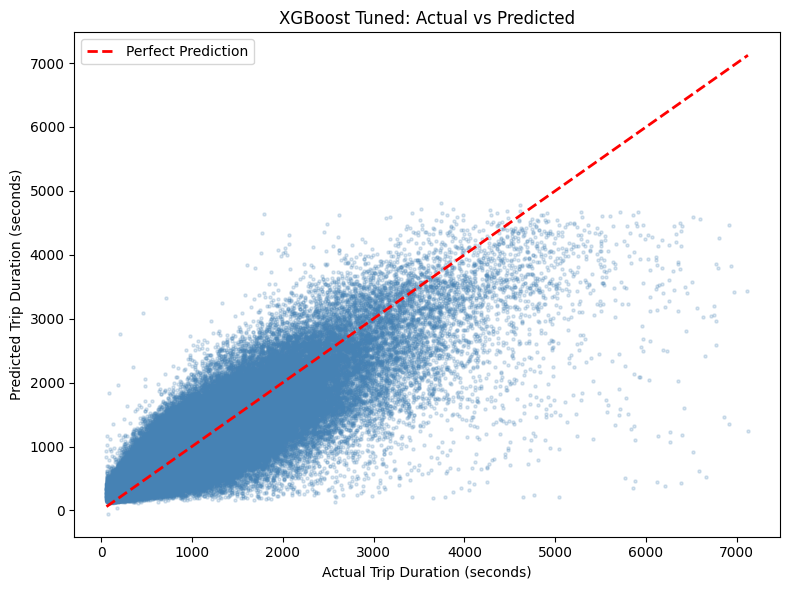

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.2, color='steelblue', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Trip Duration (seconds)")
plt.ylabel("Predicted Trip Duration (seconds)")
plt.title("XGBoost Tuned: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

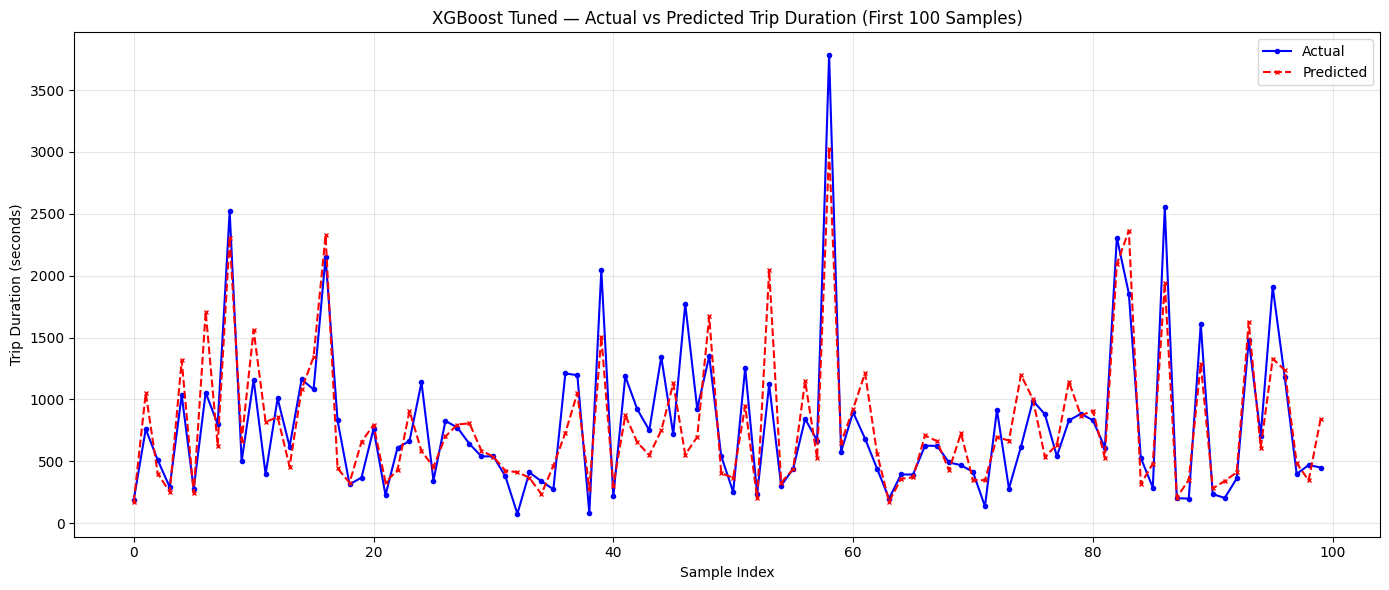

In [40]:
# Take first 100 rows for clean visibility
sample = comparison.head(100)

plt.figure(figsize=(14, 6))

plt.plot(sample.index, sample['Actual (seconds)'],
         color='blue', label='Actual', linewidth=1.5, marker='o', markersize=3)

plt.plot(sample.index, sample['Predicted (seconds)'],
         color='red', label='Predicted', linewidth=1.5,
         linestyle='--', marker='x', markersize=3)

plt.xlabel("Sample Index")
plt.ylabel("Trip Duration (seconds)")
plt.title("XGBoost Tuned — Actual vs Predicted Trip Duration (First 100 Samples)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Calculate error percentage
comparison['Error (%)'] = (
    abs(comparison['Actual (seconds)'] - comparison['Predicted (seconds)'])
    / comparison['Actual (seconds)'] * 100
).round(2)

# Total overall error percentage
total_actual    = comparison['Actual (seconds)'].sum()
total_predicted = comparison['Predicted (seconds)'].sum()
total_error_pct = abs(total_actual - total_predicted) / total_actual * 100

print("📊 Total Error Percentage:")
print(f"   Total Actual    : {total_actual:,.0f} sec")
print(f"   Total Predicted : {total_predicted:,.0f} sec")
print(f"   Total Error %   : {total_error_pct:.2f}%")

# Count of worst predictions by error bucket
print("\n📋 Number of Predictions by Error Range:")
bins   = [0, 10, 20, 30, 50, 100, float('inf')]
labels = ['0-10%', '10-20%', '20-30%', '30-50%', '50-100%', '100%+']
comparison['Error Bucket'] = pd.cut(comparison['Error (%)'], bins=bins, labels=labels)
bucket_counts = comparison['Error Bucket'].value_counts().sort_index()
for bucket, count in bucket_counts.items():
    pct = count / len(comparison) * 100
    print(f"   {bucket:<10} → {count:>7,} predictions  ({pct:.1f}%)")

print(f"\n   Total Predictions : {len(comparison):,}")

📊 Total Error Percentage:
   Total Actual    : 242,246,994 sec
   Total Predicted : 242,164,864 sec
   Total Error %   : 0.03%

📋 Number of Predictions by Error Range:
   0-10%      →  69,182 predictions  (24.0%)
   10-20%     →  61,401 predictions  (21.3%)
   20-30%     →  48,045 predictions  (16.7%)
   30-50%     →  56,032 predictions  (19.5%)
   50-100%    →  38,794 predictions  (13.5%)
   100%+      →  14,565 predictions  (5.1%)

   Total Predictions : 288,050


In [43]:
# ── Total Error Rate ─────────────────────────────────────
total_actual    = comparison['Actual (seconds)'].sum()
total_predicted = comparison['Predicted (seconds)'].sum()
total_error     = abs(total_actual - total_predicted)
total_error_pct = (total_error / total_actual) * 100

print("📊 Total Error Rate:")
print(f"   Total Error     : {total_error:,.0f} sec")
print(f"   Total Error %   : {total_error_pct:.2f}%")

# ── Worst Errors Count ───────────────────────────────────
comparison['Error (%)'] = (
    abs(comparison['Actual (seconds)'] - comparison['Predicted (seconds)'])
    / comparison['Actual (seconds)'] * 100
).round(2)

worst_count = len(comparison[comparison['Error (%)'] > 50])
very_worst  = len(comparison[comparison['Error (%)'] > 100])

print(f"\n🔴 Number of Worst Errors:")
print(f"   Error > 50%  : {worst_count:,} predictions")
print(f"   Error > 100% : {very_worst:,} predictions")

# ── Top 10 Worst Predictions ─────────────────────────────
print(f"\n⛔ Top 10 Worst Predictions:")
worst_10 = comparison.nlargest(10, 'Error (%)')[
    ['Actual (minutes)', 'Predicted (minutes)', 'Error (seconds)', 'Error (%)']
]
print(worst_10.to_string(index=True))

📊 Total Error Rate:
   Total Error     : 82,130 sec
   Total Error %   : 0.03%

🔴 Number of Worst Errors:
   Error > 50%  : 53,359 predictions
   Error > 100% : 14,565 predictions

⛔ Top 10 Worst Predictions:
        Actual (minutes)  Predicted (minutes)  Error (seconds)  Error (%)
95260               1.47            30.530001          1743.98    1981.80
100117              1.07            19.490000          1105.44    1727.25
121094              1.00            15.460000           867.84    1446.40
167758              1.12            17.200001           964.86    1440.09
44217               1.00            14.070000           783.91    1306.51
241171              3.45            46.060001          2556.63    1235.08
66655               1.70            18.709999          1020.50    1000.49
135477              2.13            22.590000          1227.24     958.78
245597              1.13            11.680000           632.52     930.18
198784              3.20            32.750000      

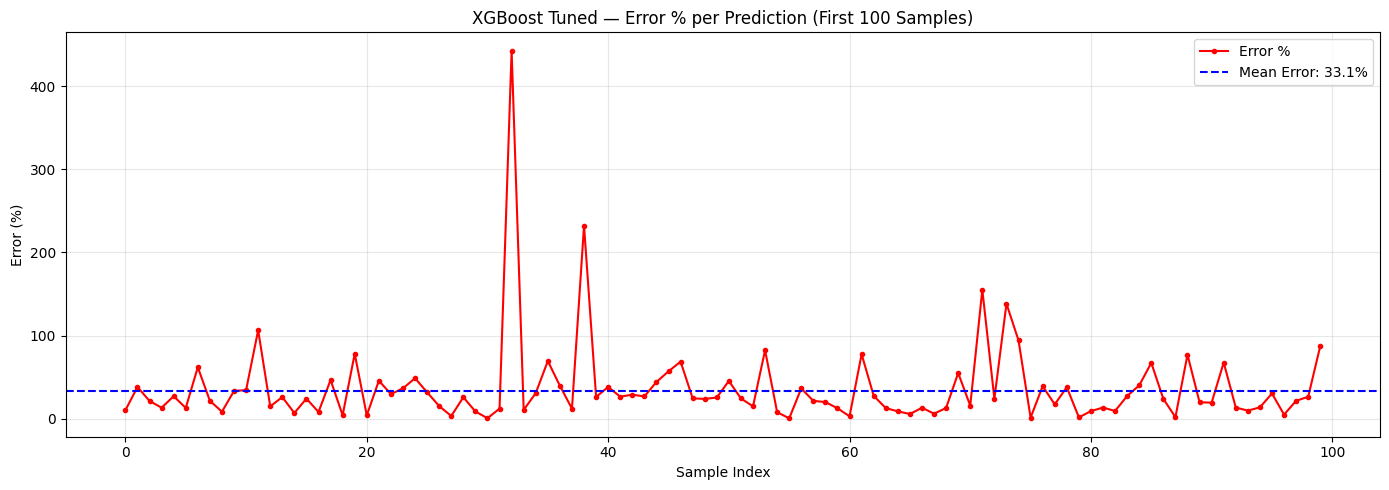

In [44]:
sample = comparison.head(100)

plt.figure(figsize=(14, 5))
plt.plot(sample.index, sample['Error (%)'],
         color='red', linewidth=1.5, marker='o', markersize=3, label='Error %')

plt.axhline(y=comparison['Error (%)'].mean(), color='blue',
            linestyle='--', linewidth=1.5, label=f"Mean Error: {comparison['Error (%)'].mean():.1f}%")

plt.xlabel("Sample Index")
plt.ylabel("Error (%)")
plt.title("XGBoost Tuned — Error % per Prediction (First 100 Samples)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()